# Query 3 - Detect stations that do not cover the demand 
Using Voronoi diagrams to find some stations in the city 

In [1]:
import os
import sys
import pandas as pd
import geopandas as gpd
import json
from shapely.geometry import shape

# Get the absolute path of the directory one level up (your project root)
# If your notebook is in /project/notebooks/, this points to /project/
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

# Add it to sys.path so Python can find 'src'
if project_root not in sys.path:
    sys.path.append(project_root)

# Now Python can successfully find the 'src' module
from src.db_upload._db import connect, execute, fetch_all

conn = connect()

In [ ]:
query = """
WITH bcn_boundary AS (
    -- 1. FAST BORDER: Union valid districts, simplify, and repair topology
    SELECT ST_MakeValid(ST_Simplify(ST_Union(ST_MakeValid(geom)), 0.001)) AS geom 
    FROM districts
),
voronoi_collection AS (
    -- 2. Generate the Voronoi diagram covering the bounding box
    SELECT ST_VoronoiPolygons(ST_Collect(geom), 0.0, (SELECT geom FROM bcn_boundary)) AS geom
    FROM stations
),
voronoi_polygons AS (
    -- 3. Split into individual polygons
    SELECT (ST_Dump(geom)).geom AS v_geom
    FROM voronoi_collection
),
clipped_voronoi AS (
    -- 4. Clip the Voronoi polygons to the exact boundary of Barcelona
    SELECT ST_Intersection(v.v_geom, b.geom) AS clipped_geom
    FROM voronoi_polygons v
    CROSS JOIN bcn_boundary b 
),
station_voronoi AS (
    -- 5. Match back to station using Intersects (safer than Within for floating points)
    SELECT 
        s.station_id AS station_id,
        s.name AS name,
        -- FIX 1: Cap the Voronoi cell to a max 1.5km radius around the station to avoid the edge effect
        ST_Intersection(cv.clipped_geom, ST_Buffer(s.geom::geography, 1500)::geometry) AS realistic_geom
    FROM stations s
    JOIN clipped_voronoi cv 
      ON ST_Intersects(s.geom, cv.clipped_geom)
),
station_usage AS (
    -- 6. Compute the time-weighted average of expected bikes
    SELECT 
        station_id,
        twavg(bikes_history) AS expected_avg_bikes
    FROM station_status_mdb
)
SELECT 
    sv.station_id, 
    sv.name,
    -- FIX 2: Return readable GeoJSON instead of Hexadecimal WKB
    ST_AsGeoJSON(sv.realistic_geom) AS voronoi_geojson,
    -- Calculate the area on the capped, realistic geometry
    ST_Area(ST_Transform(sv.realistic_geom, 25831)) AS area_sqm,
    su.expected_avg_bikes
FROM station_voronoi sv
LEFT JOIN station_usage su 
  ON sv.station_id = su.station_id
ORDER BY 
    area_sqm desc;

"""

In [15]:
results = fetch_all(conn, query)

In [16]:
print(results)

[(1, 'GRAN VIA CORTS CATALANES, 760', '{"type":"Point","coordinates":[2.1801,41.398]}', 0.0, 19.004014536045208), (2, 'C/ ROGER DE FLOR, 126', '{"type":"Point","coordinates":[2.1772,41.3955]}', 0.0, 8.430925245914116), (3, ' C/ NÀPOLS, 82', '{"type":"Point","coordinates":[2.1813,41.3942]}', 0.0, 11.412108297342035), (4, 'C/ RIBES, 13', '{"type":"Point","coordinates":[2.1812,41.3933]}', 0.0, 7.338952415380811), (5, 'PG. LLUIS COMPANYS, 11 (ARC TRIOMF)', '{"type":"Point","coordinates":[2.1802,41.3911]}', 0.0, 9.517228257767462), (6, 'PG. LLUIS COMPANYS, 18 (ARC TRIOMF)', '{"type":"Point","coordinates":[2.1806,41.3914]}', 0.0, 9.784813257482067), (7, 'PG. PUJADES,  1 (JUTJATS)', '{"type":"Point","coordinates":[2.1833,41.3889]}', 0.0, 14.567248235316502), (8, 'PG. PUJADES, 2', '{"type":"Point","coordinates":[2.1835,41.3891]}', 0.0, 13.494568009284803), (9, "AV. MARQUÉS DE L'ARGENTERA,13", '{"type":"Point","coordinates":[2.1849,41.3845]}', 0.0, 15.810498677676517), (10, 'C/ 60, NÚMERO 25', 

In [17]:
import pandas as pd
import geopandas as gpd
import json
from shapely.geometry import shape

# 1. Provide the exact column names from your SQL SELECT statement
columns = ['station_id', 'name', 'voronoi_geojson', 'area_sqm', 'expected_avg_bikes']

# 2. Create the DataFrame WITH the column names
df = pd.DataFrame(results, columns=columns)

# 3. Convert the 'voronoi_geojson' strings into actual Shapely geometry objects
df['geometry'] = df['voronoi_geojson'].apply(lambda x: shape(json.loads(x)))

# 4. Create a GeoDataFrame (explicitly stating the coordinates are WGS84 / EPSG:4326)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

# 5. Plot the interactive map! 
interactive_map = gdf.explore(
    column="expected_avg_bikes",      
    cmap="YlOrRd",                    
    tooltip=[                         
        "station_id", 
        "name",                       # <--- CHANGED FROM 'street' TO 'name' TO MATCH SQL
        "expected_avg_bikes", 
        "area_sqm"
    ],
    popup=True,                       
    legend=True,                      
    tiles="CartoDB positron",         
    style_kwds={"weight": 1.5, "color": "black", "fillOpacity": 0.7} 
)

# 6. Display or Save the map
display(interactive_map)
#interactive_map.save("../../bicing_voronoi_deserts.html")
#print("✅ Map saved successfully as 'bicing_voronoi_deserts.html'")

Pearson Correlation Coefficient: nan


c:\Users\Adria Espinoza\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Adria Espinoza\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


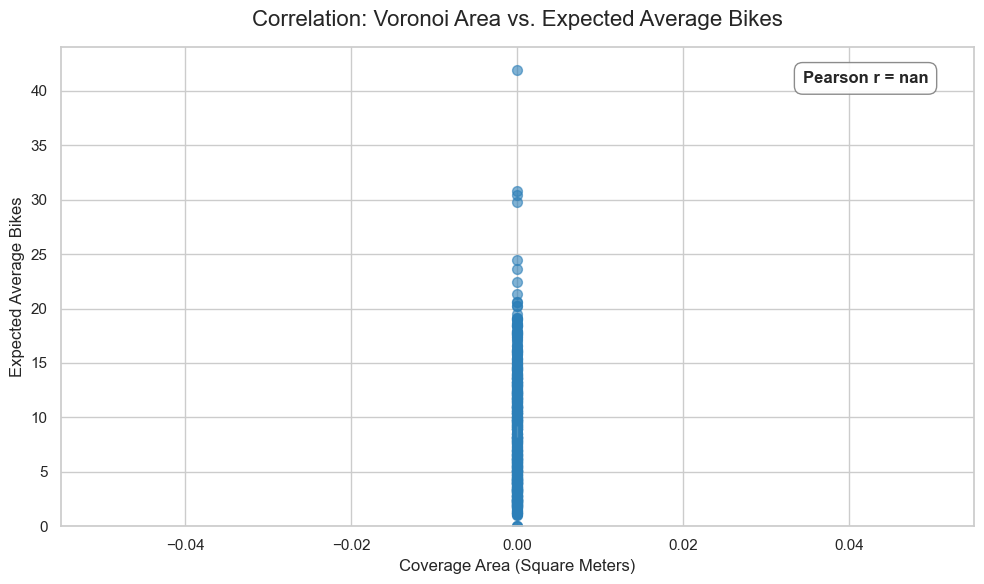

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is already loaded:
# df = pd.DataFrame(results)

# 1. Calculate the Pearson correlation coefficient
correlation = df['area_sqm'].corr(df['expected_avg_bikes'])
print(f"Pearson Correlation Coefficient: {correlation:.4f}")

# 2. Set up the plotting style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Create a scatter plot with a regression line
ax = sns.regplot(
    data=df, 
    x='area_sqm', 
    y='expected_avg_bikes',
    scatter_kws={'alpha': 0.6, 'color': '#2c7fb8', 's': 50}, # s is the size of dots
    line_kws={'color': '#e34a33', 'linewidth': 2},
    truncate=True # <--- ADDED: Stops the regression line at the data limits
)

# 4. Add formatting and labels
plt.title('Correlation: Voronoi Area vs. Expected Average Bikes', fontsize=16, pad=15)
plt.xlabel('Coverage Area (Square Meters)', fontsize=12)
plt.ylabel('Expected Average Bikes', fontsize=12)

# <--- ADDED: Force the Y-axis to start at 0 (no negative bikes)
plt.ylim(bottom=0) 

# 5. Annotate the plot with the correlation coefficient
plt.text(
    0.95, 0.95, 
    f'Pearson r = {correlation:.3f}', 
    horizontalalignment='right', 
    verticalalignment='top', 
    transform=ax.transAxes,
    fontsize=12,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5')
)

# 6. Render the plot
plt.tight_layout()
plt.show()

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from geocube.api.core import make_geocube

# 1. Ensure your data is in a metric projection (EPSG:25831 for Barcelona)
# This is crucial so we can define pixel resolution in meters, not degrees!
gdf_metric = gdf.to_crs("EPSG:25831")

# 2. CREATE THE RASTER (Replicating "Point to Raster")
# We specify a resolution of 50x50 meter pixels. 
# (The Y-axis resolution is negative, which is standard raster behavior to draw top-to-bottom)
raster_grid = make_geocube(
    vector_data=gdf_metric,
    measurements=["expected_avg_bikes"],
    resolution=(-50, 50) 
)

# 3. Visualize the Raster through space
fig, ax = plt.subplots(figsize=(10, 8))

# xarray has a built-in .plot() method that handles the map axes automatically
raster_grid["expected_avg_bikes"].plot(
    ax=ax, 
    cmap="YlOrRd", 
    cbar_kwargs={'label': 'Expected Avg Bikes'}
)

ax.set_title("Raster Map: Expected Average Bikes (50m Resolution)", fontsize=16)
ax.set_axis_off() # Hides the axis numbers for a cleaner map
plt.tight_layout()
plt.show()

IndexError: index out of range

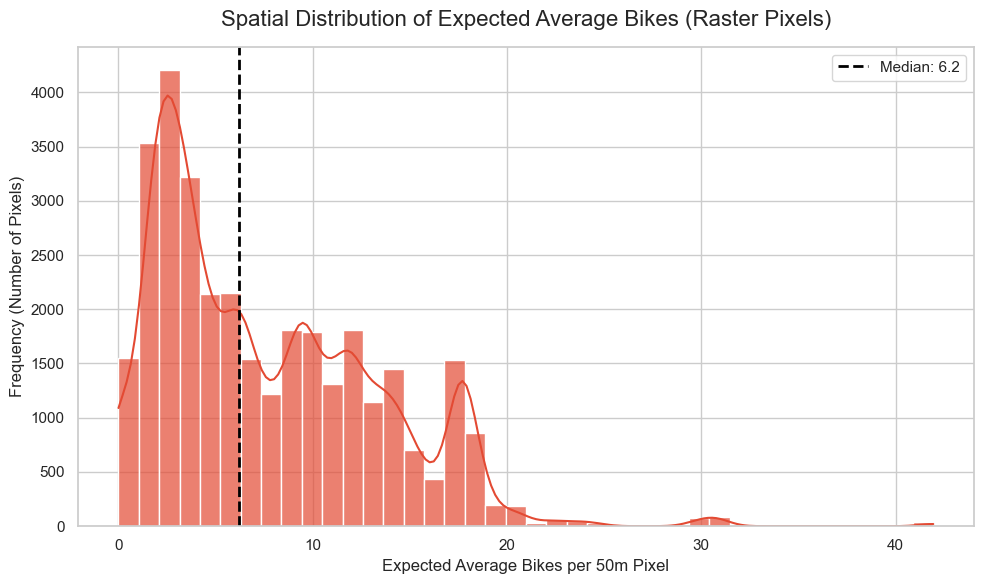

In [12]:
# 1. Extract the raw numerical matrix from the raster
raw_matrix = raster_grid["expected_avg_bikes"].values

# 2. Flatten the 2D grid into a 1D list of pixels
flat_pixels = raw_matrix.flatten()

# 3. Filter out the NaN values (pixels that are over the ocean or outside the city)
valid_pixels = flat_pixels[~np.isnan(flat_pixels)]

# 4. CREATE THE CHART (Replicating "Create Chart -> Histogram")
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plot the distribution using seaborn
sns.histplot(valid_pixels, bins=40, kde=True, color="#e34a33", alpha=0.7)

plt.title('Spatial Distribution of Expected Average Bikes (Raster Pixels)', fontsize=16, pad=15)
plt.xlabel('Expected Average Bikes per 50m Pixel', fontsize=12)
plt.ylabel('Frequency (Number of Pixels)', fontsize=12)

# Add a vertical line for the median to add some analytical value
plt.axvline(np.median(valid_pixels), color='black', linestyle='dashed', linewidth=2, label=f'Median: {np.median(valid_pixels):.1f}')
plt.legend()

plt.tight_layout()
plt.show()

✅ Static map saved successfully as 'kpi4_voronoi_deserts_static.png'


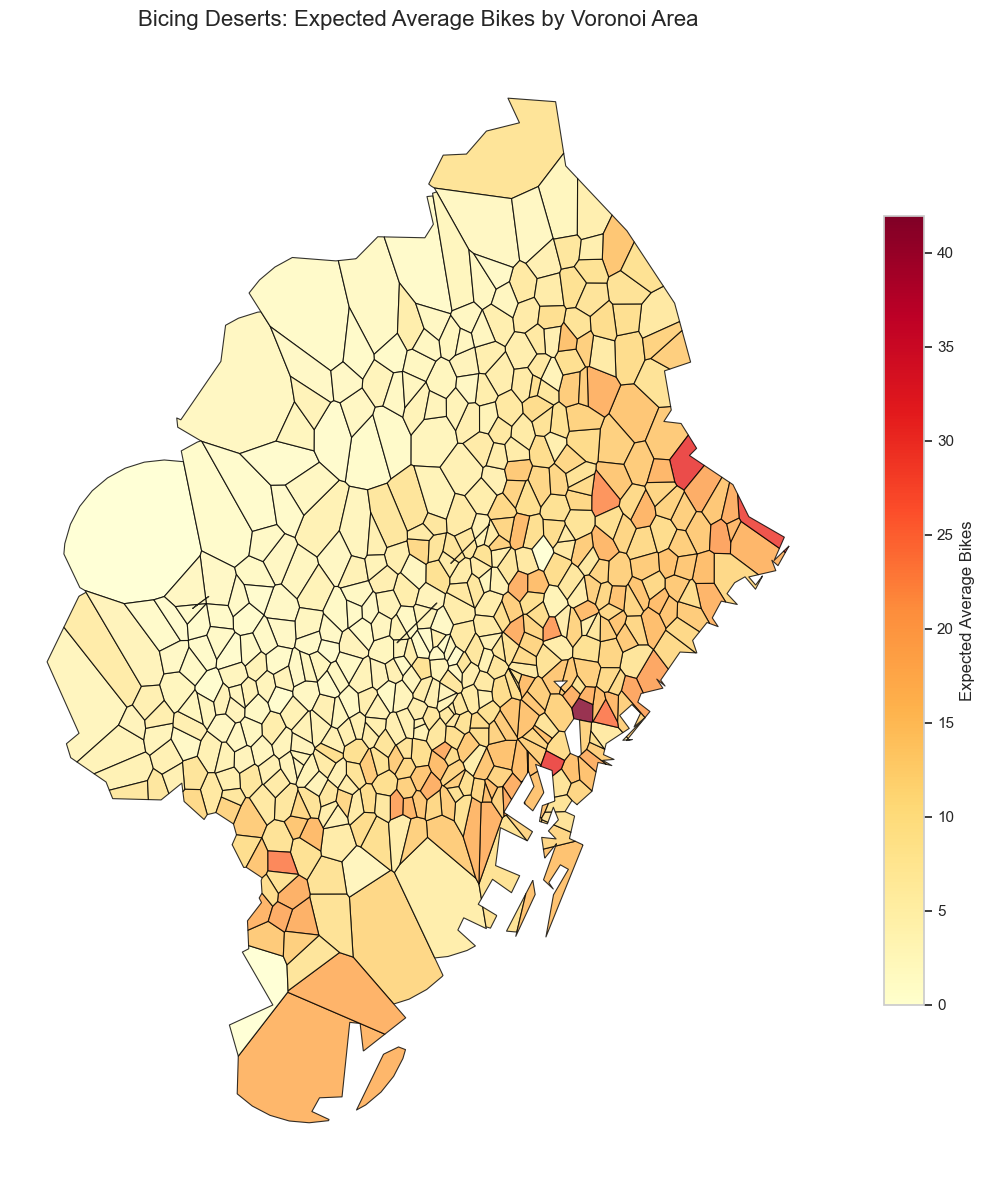

In [13]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import json
from shapely.geometry import shape

# 1 & 2 & 3. Load and prepare data (same as before)
# df = pd.DataFrame(results)
# df['geometry'] = df['voronoi_geojson'].apply(lambda x: shape(json.loads(x)))
# gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

# 4. Create the Matplotlib Figure and Axes
fig, ax = plt.subplots(figsize=(12, 12))

# 5. Plot the static map
gdf.plot(
    ax=ax,
    column="expected_avg_bikes",      # The metric for the color scale
    cmap="YlOrRd",                    # Color map (Yellow to Orange to Red)
    edgecolor="black",                # Polygon border color
    linewidth=0.8,                    # Polygon border thickness
    alpha=0.8,                        # Transparency (similar to fillOpacity)
    legend=True,                      # Add a color bar legend
    legend_kwds={
        'label': "Expected Average Bikes", 
        'orientation': "vertical",
        'shrink': 0.7                 # Shrinks the colorbar slightly to fit the plot
    }
)

# 6. Add titles and clean up the axes
plt.title("Bicing Deserts: Expected Average Bikes by Voronoi Area", fontsize=16, pad=15)
ax.set_axis_off()                     # Hide the latitude/longitude axes for a cleaner look

# 7. Display and Save
plt.tight_layout()

# Save as a high-resolution PNG image
plt.savefig("../../kpi4_voronoi_deserts_static.png", dpi=300, bbox_inches='tight')
print("✅ Static map saved successfully as 'kpi4_voronoi_deserts_static.png'")

# Show the plot inline
plt.show()